In [1]:
import cv2
import matplotlib.pyplot as plt

## Configurable parameters of the object detection algorithm

1. d = Gaussian Kernel Size. [height width]. height and width should be **odd** and can have different values. If ksize is set to [0 0], then ksize is computed from sigma values.
2. LO/UP = Lower/Upper bounds for the contour size filter depending on individual lengths.
3. block_size = The size of the neighbourhood area used to calculate the adaptive thresholding. 
    - Adaptive threshold value = mean(pixel intensity) – C
4. c = A tuning parameter. A constant value used in the adaptive threshold value calculation.

## A set of pre defined parameter values to be used

In [34]:
path = '.\\..\\Data\\third_set\\cropped\\SWR2_MERTRIP1_2021_SML_2_C.JPG'

# For Gaussian Blur
d = 21

#For contour size
LO = 10
UP = 3000

#For Gaussian adaptive threshold
block_size = 151
C = -70

In [32]:
# Adaptive Mean thresholding

# Adaptive Mean thresholding

def compare(path,d,LO,UP,block_size,C):
    fig, axes = plt.subplots(2,1, figsize=(40,20))
    img = cv2.imread(path)
    img_col = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    axes[0].imshow(img_col)
    axes[0].set_title('RGB image')
    b,g,r = cv2.split(img)
    blur = cv2.GaussianBlur(r,(d,d),0)
    thresh_cv = cv2.adaptiveThreshold(blur,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY, block_size,C)
    contours, hierarchy = cv2.findContours(thresh_cv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    cnt_large = []
    lens_cnt_large = []
    img_l = img
    for cnts in contours:
        if (cv2.arcLength(cnts,True)> LO) and (cv2.arcLength(cnts,True)<UP):
            cnt_large.append(cnts)
            lens_cnt_large.append(cv2.arcLength(cnts,True))

    cv2.drawContours(img_l, cnt_large, -1, (255,0,0),5)
    axes[1].imshow(img_l)

    print('*'*90)
    print('Counted number of plastics: ',len(cnt_large))

******************************************************************************************
Counted number of plastics:  41


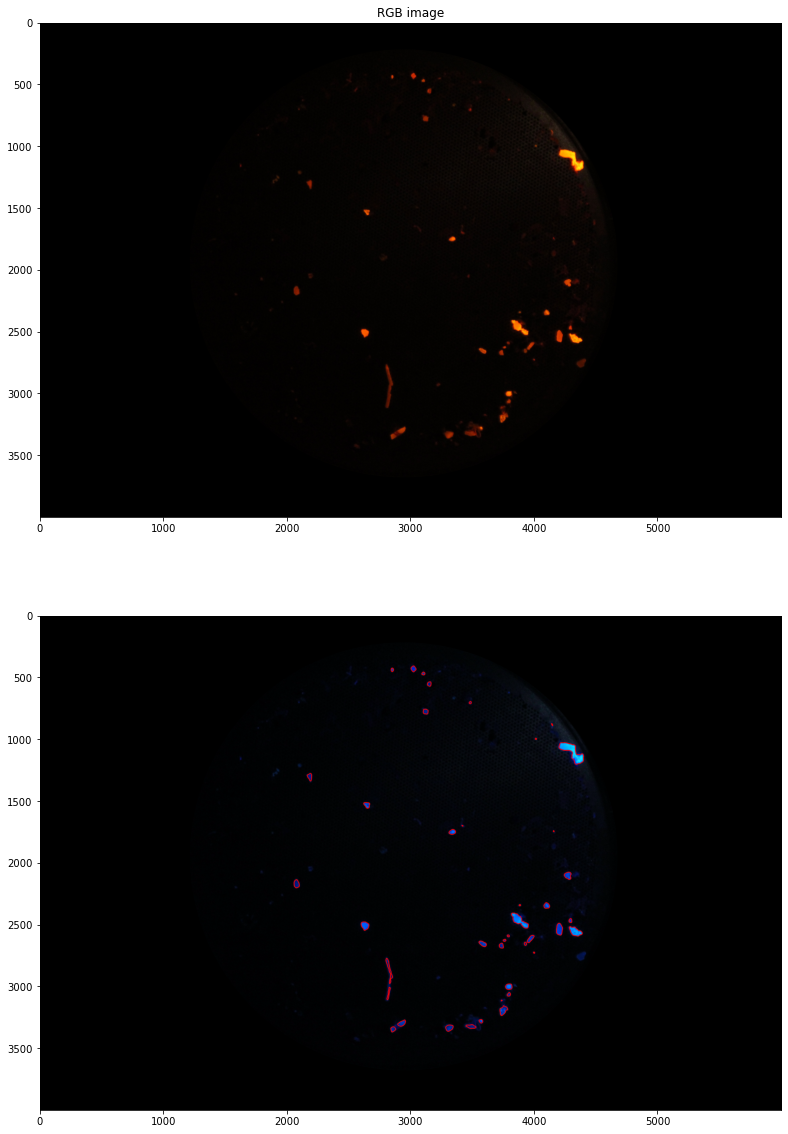

In [35]:
compare(path,d,LO,UP,block_size,C)

## Checking the sensitivity of the parameters

### 1. d = Gaussian Kernel Size
#### We now change the blur size and see how the results change

In [36]:
#same image
path = '.\\..\\Data\\third_set\\cropped\\SWR2_MERTRIP1_2021_SML_2_C.JPG'

# For Gaussian Blur
d = 51


# Other parameters not changed

#For contour size
LO = 10
UP = 3000

#For Gaussian adaptive threshold
block_size = 151
C = -70

******************************************************************************************
Counted number of plastics:  33


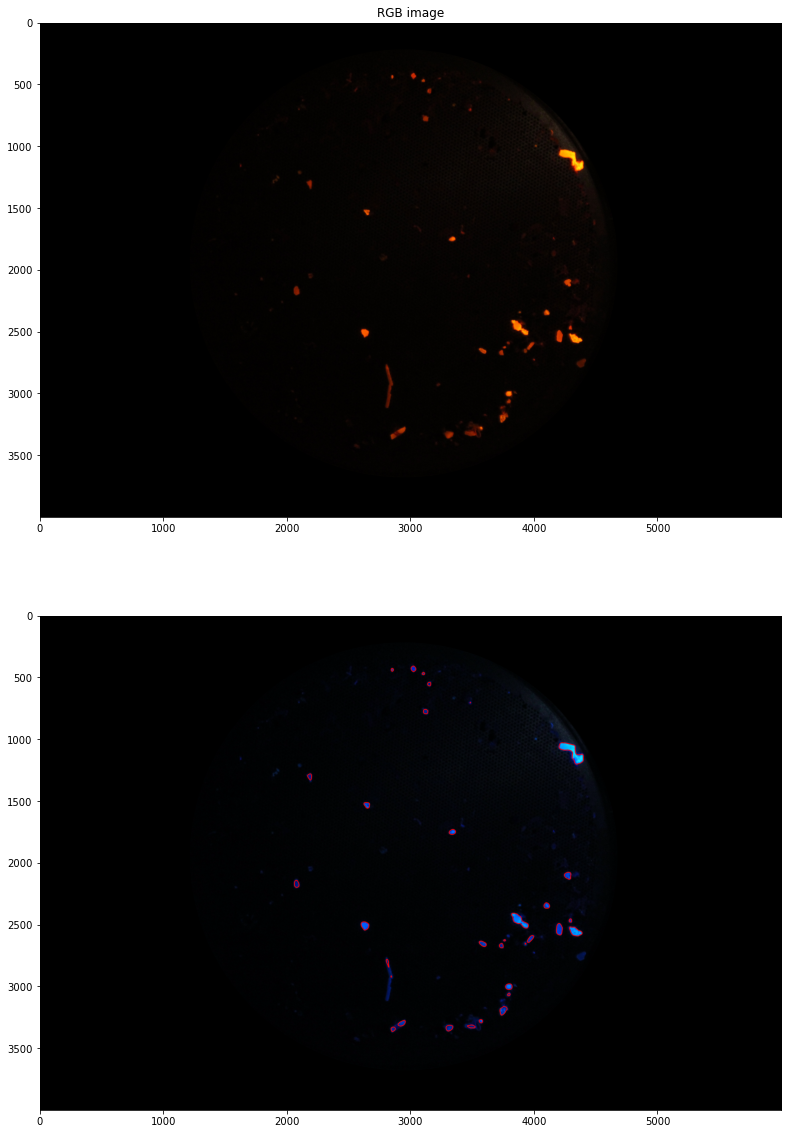

In [37]:
compare(path,d,LO,UP,block_size,C)

In [27]:
## As we can see in the above comparison, a higher value of 'd' will smoothen out the noise in the image. 
## This can be particularly useful when the image has patches which can be considered as noise (and not plastic)!

In [39]:
#same image
path = '.\\..\\Data\\third_set\\cropped\\SWR2_MERTRIP1_2021_SML_2_C.JPG'

# For Gaussian Blur
d = 3

# Other parameters not changed

#For contour size
LO = 10
UP = 3000

#For Gaussian adaptive threshold
block_size = 151
C = -70


******************************************************************************************
Counted number of plastics:  45


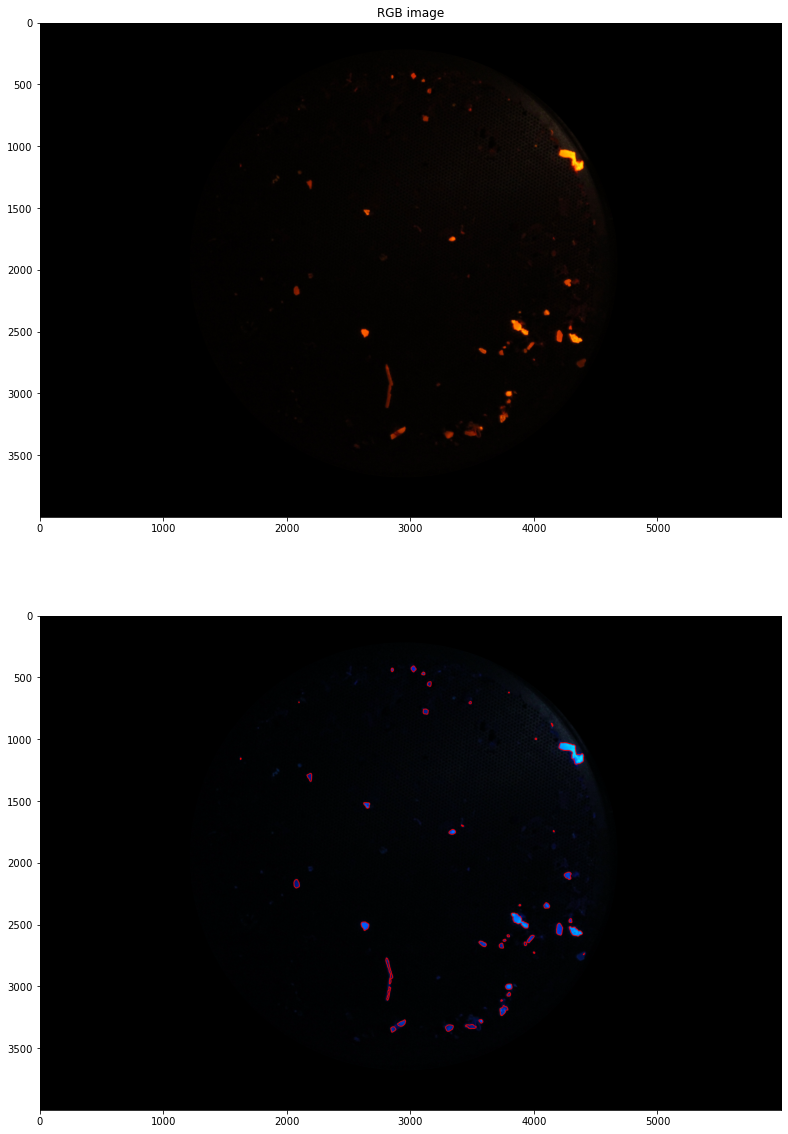

In [40]:
compare(path,d,LO,UP,block_size,C)

In [41]:
## The algorithm becomes more aggressive and pick even the minute features which can be noise in the image

### 2. block_size
#### We now change the block size and see how the results change

In [42]:
#same image
path = '.\\..\\Data\\third_set\\cropped\\SWR2_MERTRIP1_2021_SML_2_C.JPG'

# For Gaussian Blur
d = 21

#For contour size
LO = 10
UP = 3000

#For Gaussian adaptive threshold
# Change the block size
block_size = 51
C = -70

******************************************************************************************
Counted number of plastics:  46


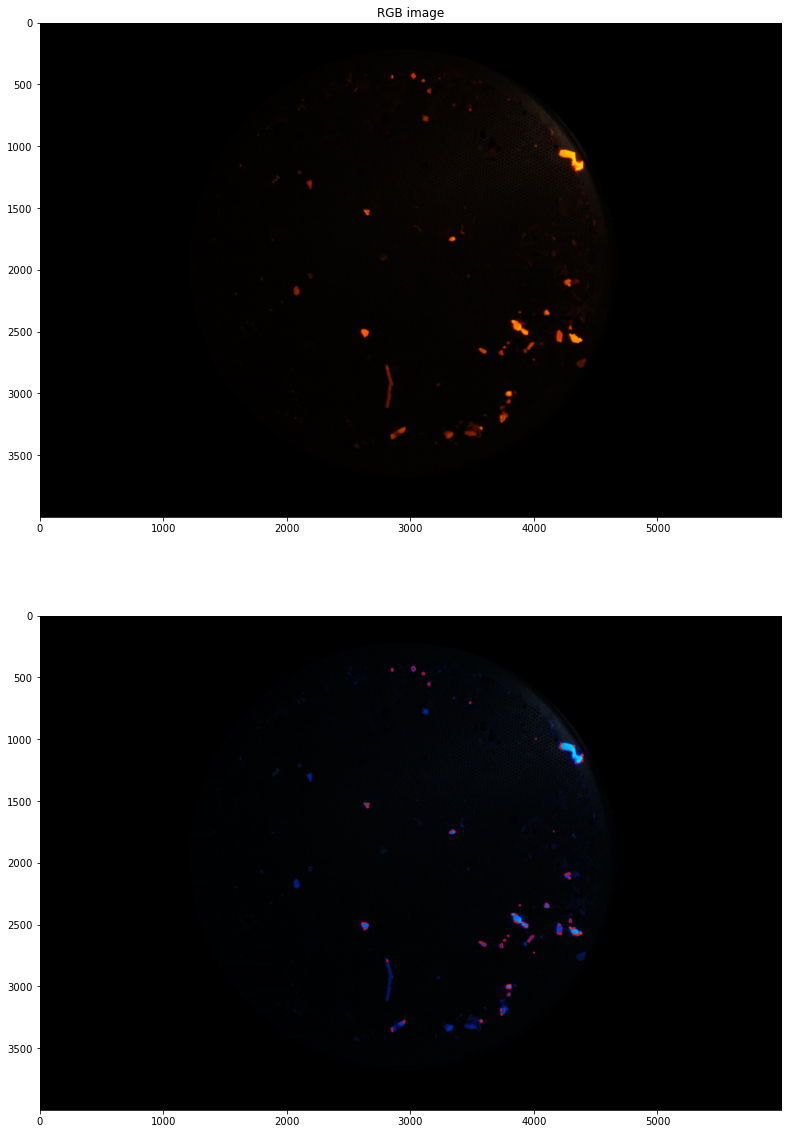

In [43]:
compare(path,d,LO,UP,block_size,C)

In [44]:
## Clearly the neighborhood is too small for the adaptive thresholding value calculation!

In [45]:
#same image
path = '.\\..\\Data\\third_set\\cropped\\SWR2_MERTRIP1_2021_SML_2_C.JPG'

# For Gaussian Blur
d = 21

#For contour size
LO = 10
UP = 3000

#For Gaussian adaptive threshold
# Change the block size
block_size = 551
C = -70

******************************************************************************************
Counted number of plastics:  41


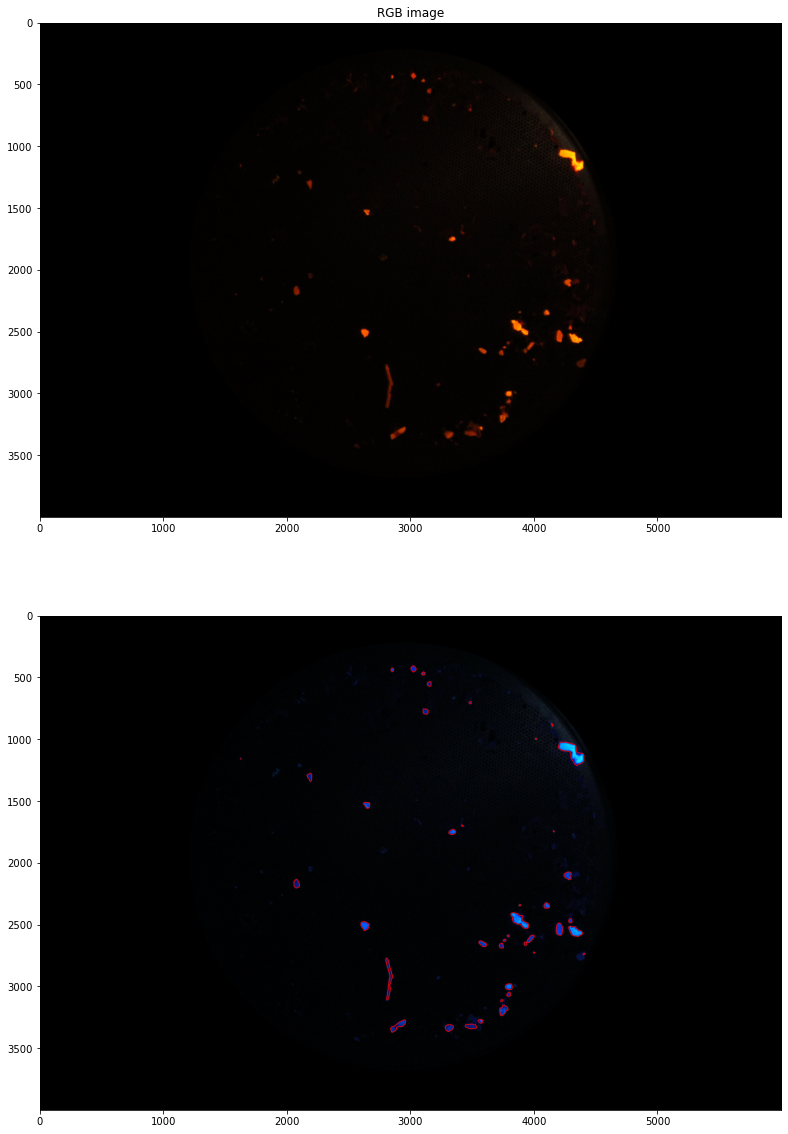

In [46]:
compare(path,d,LO,UP,block_size,C)

Looks like the adaptive thresholding boundary size has a upper bound above which the gain is negligible

However, this parameter has a inetraction effect, so best used in combination with the correction factor 'C'

In other words, the optimum space is a multivariate normal comprised of both the 'block size' and 'c'. 
If oneprefers to find the optimum conditional on a fixed/given block_size, better to test and see if the upper bound is reached.
This depends on the brightness of each pixel. Things like the amount of dye used, the wetness when the dye was applied and the lighting changes 
can ruin the fixed set of parameters. Best is to trial and error with atleast few i,ages for each batch of dyed photographs.


### 3. 'c' the correction factor
#### We now change 'c' and see how the results change

In [50]:
#same image
path = '.\\..\\Data\\third_set\\cropped\\SWR2_MERTRIP1_2021_SML_2_C.JPG'

# For Gaussian Blur
d = 21

#For contour size
LO = 10
UP = 3000

#For Gaussian adaptive threshold
block_size = 151
C = -10

******************************************************************************************
Counted number of plastics:  119


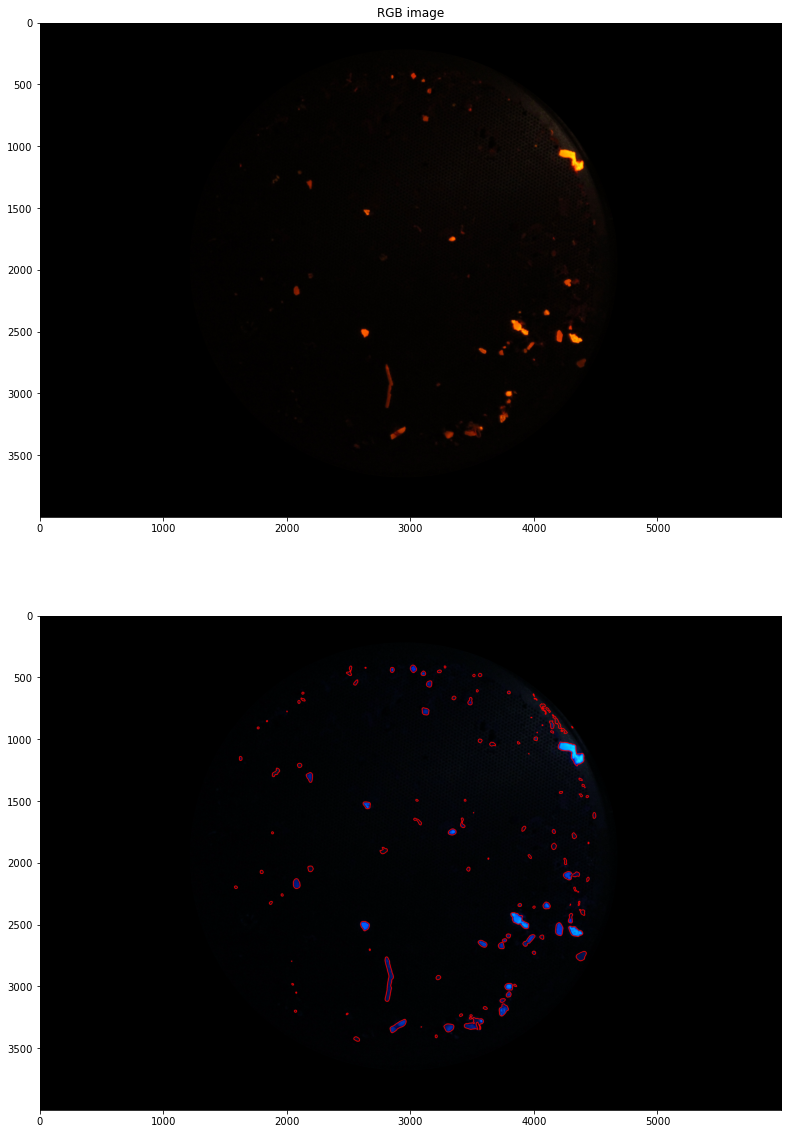

In [51]:
compare(path,d,LO,UP,block_size,C)

It might seem a very wrong answer but actually it is not.

Wipe your dusty screen and you might (just) be able to see the faint differences in the brightness in the image. The correction factor alters our thresholding to a very tinay value allowing even the slight changes in pixes brightness in a vicinity to be counted as plastic. This is (I think) the real utility of using pixel values. We actually can see more than what we can see from our naked eye. But this may be an overkill for the plastic detenction problem.

In [64]:
#same image
path = '.\\..\\Data\\third_set\\cropped\\SWR2_MERTRIP1_2021_SML_2_C.JPG'

# For Gaussian Blur
d = 21

#For contour size
LO = 10
UP = 3000

#For Gaussian adaptive threshold
block_size = 151
C = -60

******************************************************************************************
Counted number of plastics:  46


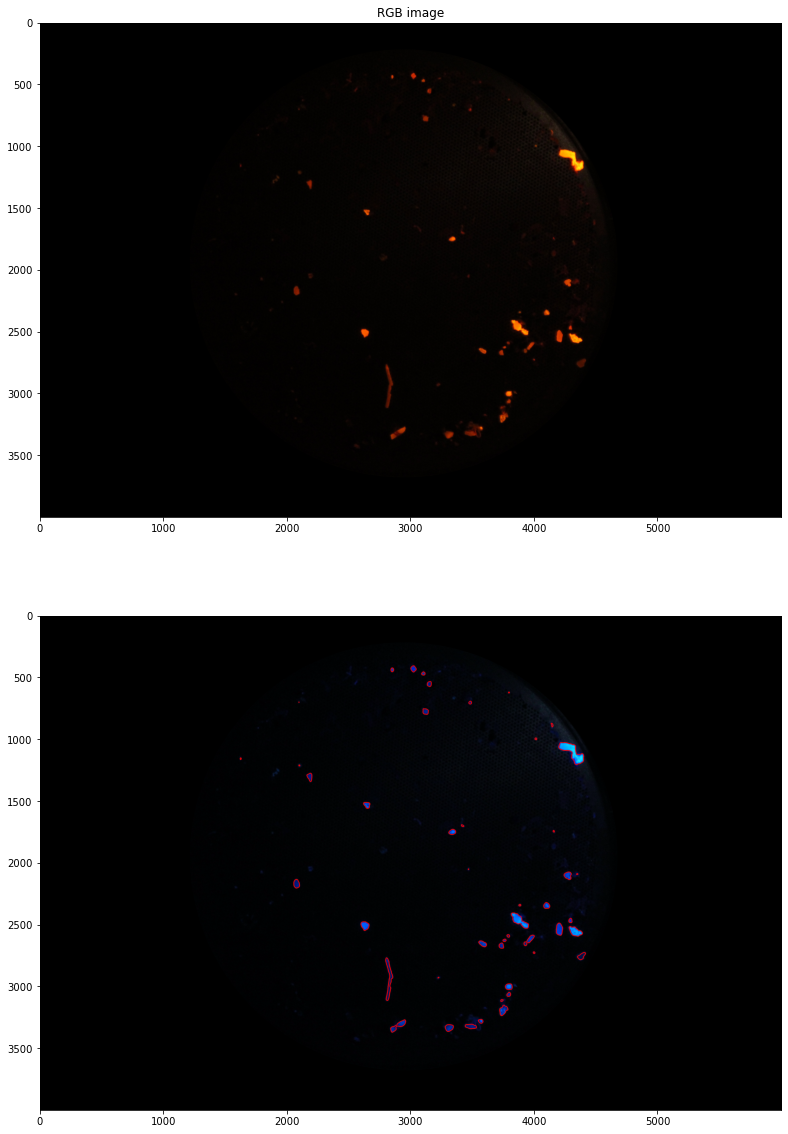

In [63]:
compare(path,d,LO,UP,block_size,C)

The 'c' value will test your confidence on 'what' you define as a plastic. This is crucial as some organic matter tend to display bright but not as much as plastic. It is 'you' the brain behind the inference who should decide this. Once you can differentiate the brightness levels, the script will automate the process and give you the answers with a consistant logic and rational that you feed into it.

## Running the script on a batch of files in a specific folder

### For those who like csv files and spending less time rerunning code.

In [4]:
import glob
import pandas as pd

In [34]:
# Source path 
source = ".\\..\\Data\\third_set\cropped"

# Destination path
destination = ".\\..\\Data\\third_set\\test_c.csv"

# Wildcard to use for the image search
wildcard = '/*SML*'

f = []
# Set the wildcard to use for the image search
for files in glob.glob(source + wildcard):
    f.append(files)
    
    
# For Gaussian Blur
d = 31

#For contour size
LO = 80
UP = 1000

#For Gaussian adaptive threshold
block_size = 501
C = -5000

# Show results for each image?

show_res = 'Yes'

# Object count

OC = []
for file in f: 
    img = cv2.imread(file)
    b,g,r = cv2.split(img)
    blur = cv2.GaussianBlur(r,(d,d),0)
    thresh_cv = cv2.adaptiveThreshold(blur,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY, 301,-50)
    contours, hierarchy = cv2.findContours(thresh_cv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    cnt_large = []
    lens_cnt_large = []
    img_l = img
    for cnts in contours:
        if (cv2.arcLength(cnts,True)> LO) and (cv2.arcLength(cnts,True)<UP):
            cnt_large.append(cnts)
            lens_cnt_large.append(cv2.arcLength(cnts,True))
    if show_res == 'Yes':
        cv2.drawContours(img_l, cnt_large, -1, (255,0,0),5)
        #plt.figure(figsize=(20,20))
        cv2.namedWindow('Img_l', cv2.WINDOW_NORMAL)

        #ims = cv2.resize(img, (100,100))
        cv2.imshow('Img_l',cv2.cvtColor(img_l,cv2.COLOR_BGR2RGB))
        cv2.waitKey(0)
        cv2.destroyAllWindows()
    else:
        
        OC.append(len(cnt_large))

if show_res == 'No':
    res_dict = {'File path': f, 'Count': OC}

    df = pd.DataFrame.from_dict(res_dict)

    df.to_csv(destination)
    
else:
    pass
        